# Visible Range Estimator y Recorte Thoracolumbar Explicado - Colab

Este notebook ataca directamente el problema que vimos en las etapas anteriores:
el modelo multiclase suele extender la secuencia de vertebras mas alla del rango
realmente visible en radiografias parciales.

## Idea central

En lugar de intentar corregir solo la mascara final con reglas locales, entrenamos
un modelo supervisado adicional que aprenda a responder dos preguntas:

1. cual es la **primera vertebra visible**
2. cual es la **ultima vertebra visible**

Luego usamos esa prediccion para recortar la mascara multiclase del modelo actual.

## Objetivo

Construir una nueva etapa del pipeline:

1. binario: localiza columna
2. multiclase: segmenta vertebras `T1..T12 + L1..L5`
3. visible-range estimator: predice el rango anatomico visible
4. clipping anatomico: recorta las etiquetas fuera del rango estimado

## Por que este notebook es importante

Este experimento busca atacar el fallo principal detectado:

- buena localizacion general
- segmentacion razonable
- pero sobreprediccion de vertebras no visibles en imagenes parciales

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` si la carpeta del proyecto en Google Drive tiene otro nombre
o esta en otra ubicacion.

In [1]:
import os
from pathlib import Path

#try:
    #from google.colab import drive  # type: ignore
    #drive.mount('/content/drive')
#except Exception as exc:
    #print('No se detecto entorno Colab o Drive ya estaba montado:', exc)

PROJECT_ROOT = Path('./Scoliosis_Dataset')
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'No existe PROJECT_ROOT={PROJECT_ROOT}. Ajusta esta ruta a tu carpeta real en Google Drive.'
    )

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())

Working directory: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset


## 1. Librerias, semillas y configuracion

En esta celda definimos:

- rutas del proyecto
- hiperparametros del estimador de rango visible
- checkpoints ya entrenados que reutilizaremos
- directorio de salida de esta nueva etapa

In [2]:
from __future__ import annotations

import copy
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage as ndi

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CWD = Path.cwd()

ROOT_CANDIDATES = [
    CWD,
    CWD / 'Scoliosis_Dataset',
    CWD / 'IA-MASTER/ProyectoGrado2/Scoliosis_Dataset',
    CWD.parent / 'Scoliosis_Dataset',
    Path('/content/drive/MyDrive/DataRadriografias'),
]

REQUIRED_FILES = [
    'indice_dataset.csv',
    'diccionario_etiquetas_T1_T12_L1_L5.json',
    'analysis_outputs/training_manifest_thoracolumbar.csv',
    'analysis_outputs/training_runs_binary_thoracolumbar/binary_spine_group_partition_map.csv',
    'models/binary_spine_thoracolumbar_best.pt',
    'models/thoracolumbar_partial_cascade_explained_best.pt',
]


def is_valid_root(path: Path) -> bool:
    return path.exists() and all((path / rel).exists() for rel in REQUIRED_FILES)


ROOT = next((p for p in ROOT_CANDIDATES if is_valid_root(p)), None)
assert ROOT is not None, (
    'No se pudo localizar la carpeta Scoliosis_Dataset/DataRadriografias con los archivos esperados. '
    f'Directorio actual: {CWD}'
)

ROOT = ROOT.resolve()
SEARCH_BASES = [CWD.resolve(), ROOT, *ROOT.parents]


def resolve_dataset_path(path_value: str | Path) -> Path:
    raw = Path(str(path_value))
    candidates: list[Path] = []

    if raw.is_absolute():
        candidates.append(raw)
    else:
        candidates.append(raw)
        candidates.extend(base / raw for base in SEARCH_BASES)

        parts = raw.parts
        if 'Scoliosis_Dataset' in parts:
            idx = parts.index('Scoliosis_Dataset')
            trimmed = Path(*parts[idx + 1:])
            if str(trimmed) not in {'', '.'}:
                candidates.append(ROOT / trimmed)
        if 'DataRadriografias' in parts:
            idx = parts.index('DataRadriografias')
            trimmed = Path(*parts[idx + 1:])
            if str(trimmed) not in {'', '.'}:
                candidates.append(ROOT / trimmed)

    seen: set[str] = set()
    unique_candidates: list[Path] = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate.resolve()

    return unique_candidates[-1].resolve()

INDEX_PATH = ROOT / 'indice_dataset.csv'
DICT_PATH = ROOT / 'diccionario_etiquetas_T1_T12_L1_L5.json'
MANIFEST_PATH = ROOT / 'analysis_outputs' / 'training_manifest_thoracolumbar.csv'
BINARY_GROUP_MAP_PATH = ROOT / 'analysis_outputs' / 'training_runs_binary_thoracolumbar' / 'binary_spine_group_partition_map.csv'
BINARY_MODEL_PATH = ROOT / 'models' / 'binary_spine_thoracolumbar_best.pt'
MULTICLASS_MODEL_PATH = ROOT / 'models' / 'thoracolumbar_partial_cascade_explained_best.pt'
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'visible_range_estimator_thoracolumbar_explained'
MODEL_DIR = ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for path in [INDEX_PATH, DICT_PATH, MANIFEST_PATH, BINARY_GROUP_MAP_PATH, BINARY_MODEL_PATH, MULTICLASS_MODEL_PATH]:
    if not path.exists():
        raise FileNotFoundError(f'No existe archivo requerido: {path}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
PIN_MEMORY = False
USE_AMP = DEVICE.type == 'cuda'

TARGET_SUBSET = 'partial'
IMG_SIZE_BINARY = (512, 256)
IMG_SIZE_MULTICLASS = (640, 320)
IMG_SIZE_RANGE = (384, 192)
BINARY_THRESHOLD = 0.50
ROI_PAD_X = 28
ROI_PAD_Y = 44
MIN_FOREGROUND_PIXELS = 24
IGNORE_INDEX = 255

RANGE_BATCH_SIZE = 8
RANGE_NUM_WORKERS = 0
RANGE_EPOCHS = 30
RANGE_LR = 1e-3
RANGE_WEIGHT_DECAY = 1e-4
RANGE_PATIENCE = 8
RANGE_DROPOUT = 0.20
RANGE_LABEL_SMOOTHING = 0.05

N_VIS_SAMPLES = 8

print('CWD:', CWD)
print('ROOT:', ROOT)
print('DEVICE:', DEVICE)
print('OUTPUT_DIR:', OUTPUT_DIR)

CWD: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
ROOT: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset
DEVICE: mps
OUTPUT_DIR: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained


## 2. Metadata y construccion del target supervisado

A partir de la mascara multiclase real construimos el target del nuevo modelo:

- `first_visible_idx`
- `last_visible_idx`

Cada uno corresponde a un indice dentro de:
`T1..T12 + L1..L5`

In [3]:
index_df_raw = pd.read_csv(INDEX_PATH)
manifest_df = pd.read_csv(MANIFEST_PATH)
group_map_df = pd.read_csv(BINARY_GROUP_MAP_PATH)
with open(DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

index_col_map = {
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_id_png',
}
index_df = index_df_raw.rename(columns=index_col_map).copy()

final_multiclass_map = {int(k): v for k, v in labels_dict['mascara_multiclase_id_png'].items()}
class_names = [final_multiclass_map[i] for i in range(len(final_multiclass_map))]
num_classes = len(class_names)
canonical_labels = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
label_to_class_id = {label: idx for idx, label in enumerate(class_names)}
valid_multiclass_ids = set(range(num_classes))

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = index_df[join_cols + ['label_binary_path', 'multiclass_id_png']].copy()
table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))
table['multiclass_mask_path'] = table['mask_path'].fillna(table['multiclass_id_png'])
table['radiograph_path_abs'] = table['radiograph_path'].apply(lambda rel: str(resolve_dataset_path(rel)))
table['binary_mask_path_abs'] = table['label_binary_path'].apply(lambda rel: str(resolve_dataset_path(rel)))
table['multiclass_mask_path_abs'] = table['multiclass_mask_path'].apply(lambda rel: str(resolve_dataset_path(rel)))

for col in ['usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial', 'needs_annotation_review']:
    if col in table.columns:
        table[col] = table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

group_partition_map = group_map_df.drop_duplicates().set_index('group_id_for_split')['partition'].to_dict()
table['partition'] = table['group_id_for_split'].map(group_partition_map)


def extract_visible_range_from_mask(path: str) -> tuple[int | None, int | None, list[str]]:
    raw = np.array(Image.open(path), dtype=np.int32)
    ids = sorted(int(x) for x in np.unique(raw) if int(x) in valid_multiclass_ids and int(x) > 0)
    labels = [class_names[class_id] for class_id in ids if class_names[class_id] in canonical_labels]
    if not labels:
        return None, None, []
    first_idx = canonical_labels.index(labels[0])
    last_idx = canonical_labels.index(labels[-1])
    return first_idx, last_idx, labels


subset_flag = 'usable_for_thoracolumbar_core' if TARGET_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
range_df = table.loc[
    table[subset_flag] & ~table['needs_annotation_review']
].copy().reset_index(drop=True)

first_last = range_df['multiclass_mask_path_abs'].apply(extract_visible_range_from_mask)
range_df['first_visible_idx'] = [item[0] for item in first_last]
range_df['last_visible_idx'] = [item[1] for item in first_last]
range_df['visible_labels_gt'] = [', '.join(item[2]) for item in first_last]
range_df = range_df.loc[
    range_df['first_visible_idx'].notna() & range_df['last_visible_idx'].notna()
].copy().reset_index(drop=True)
range_df['first_visible_idx'] = range_df['first_visible_idx'].astype(int)
range_df['last_visible_idx'] = range_df['last_visible_idx'].astype(int)
range_df['visible_span_len'] = range_df['last_visible_idx'] - range_df['first_visible_idx'] + 1
range_df['first_visible_label'] = range_df['first_visible_idx'].map(lambda idx: canonical_labels[int(idx)])
range_df['last_visible_label'] = range_df['last_visible_idx'].map(lambda idx: canonical_labels[int(idx)])

print('Muestras para range estimator:', len(range_df))
display(range_df.groupby('partition').size().rename('images').reset_index())
display(range_df[['partition', 'split', 'image', 'first_visible_label', 'last_visible_label', 'visible_span_len']].head(10))

Muestras para range estimator: 224


,partition,images
0,test,45
1,train,143
2,val,36


,partition,split,image,first_visible_label,last_visible_label,visible_span_len
0,train,Normal,N_1.jpg,T1,L5,17
1,train,Normal,N_2.jpg,T1,L5,17
2,val,Normal,N_3.jpg,T1,L5,17
3,test,Normal,N_4.jpg,T1,L5,17
4,train,Normal,N_5.jpg,T1,L5,17
5,test,Normal,N_6.jpg,T1,L5,17
6,train,Normal,N_7.jpg,T1,L5,17
7,test,Normal,N_8.jpg,T1,L5,17
8,train,Normal,N_9.jpg,T1,L5,17
9,train,Normal,N_10.jpg,T1,L5,17


## 3. Distribucion del target de rango visible

Antes de entrenar conviene ver si el dataset esta concentrado en ciertos inicios o
finales de secuencia visible.

In [4]:
first_dist_df = (
    range_df.groupby(['partition', 'first_visible_label'])
    .size()
    .rename('images')
    .reset_index()
    .sort_values(['partition', 'images'], ascending=[True, False])
)
last_dist_df = (
    range_df.groupby(['partition', 'last_visible_label'])
    .size()
    .rename('images')
    .reset_index()
    .sort_values(['partition', 'images'], ascending=[True, False])
)

span_summary_df = (
    range_df.groupby('partition')['visible_span_len']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

display(first_dist_df.head(20))
display(last_dist_df.head(20))
display(span_summary_df)

,partition,first_visible_label,images
0,test,T1,42
1,test,T2,3
2,train,T1,139
3,train,T2,3
4,train,T3,1
5,val,T1,33
6,val,T3,1
7,val,T4,1
8,val,T5,1


,partition,last_visible_label,images
4,test,L5,15
3,test,L4,6
2,test,L3,5
7,test,T12,5
1,test,L2,3
5,test,T10,3
6,test,T11,2
9,test,T7,2
0,test,L1,1
8,test,T6,1


,partition,count,mean,median,min,max
0,test,45,13.933333,15.0,6,17
1,train,143,14.090909,15.0,6,17
2,val,36,13.638889,14.0,6,17


## 4. Utilidades de imagen, ROI y modelos reutilizados

Reutilizamos el modelo binario ya entrenado para definir la ROI y el modelo
multiclase actual para evaluar luego el clipping por rango visible.

In [5]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def build_multiclass_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    valid_mask = np.isin(raw, list(valid_multiclass_ids))
    out[~valid_mask] = IGNORE_INDEX
    out[valid_mask] = raw[valid_mask].astype(np.uint8)
    if size is not None:
        out = resize_mask(out, size)
    return out


def bbox_from_mask(mask: np.ndarray, min_foreground_pixels: int = 24) -> tuple[int, int, int, int] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) < min_foreground_pixels:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def clamp_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    x0, y0, x1, y1 = bbox
    x0 = max(0, min(x0, w - 1))
    y0 = max(0, min(y0, h - 1))
    x1 = max(x0 + 1, min(x1, w))
    y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1


def expand_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int], pad_x: int = 28, pad_y: int = 44) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    return clamp_bbox((x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y), image_shape)


def scale_bbox(bbox: tuple[int, int, int, int], src_shape: tuple[int, int], dst_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    src_h, src_w = src_shape
    dst_h, dst_w = dst_shape
    x0, y0, x1, y1 = bbox
    sx = dst_w / src_w
    sy = dst_h / src_h
    scaled = (int(round(x0 * sx)), int(round(y0 * sy)), int(round(x1 * sx)), int(round(y1 * sy)))
    return clamp_bbox(scaled, dst_shape)


def crop_array(arr: np.ndarray, bbox: tuple[int, int, int, int]) -> np.ndarray:
    x0, y0, x1, y1 = bbox
    return arr[y0:y1, x0:x1]


def normalize_image(image_2d: np.ndarray) -> np.ndarray:
    mean = float(image_2d.mean())
    std = float(image_2d.std())
    if std < 1e-6:
        return image_2d - mean
    return (image_2d - mean) / std


def build_coordinate_channels(height: int, width: int) -> np.ndarray:
    y_coords = np.linspace(0.0, 1.0, height, dtype=np.float32)[:, None]
    x_coords = np.linspace(0.0, 1.0, width, dtype=np.float32)[None, :]
    y_map = np.repeat(y_coords, width, axis=1)
    x_map = np.repeat(x_coords, height, axis=0)
    return np.stack([y_map, x_map], axis=0)


class DoubleConvBinary(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class BinaryUNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConvBinary(in_channels, base)
        self.e2 = DoubleConvBinary(base, base * 2)
        self.e3 = DoubleConvBinary(base * 2, base * 4)
        self.e4 = DoubleConvBinary(base * 4, base * 8)
        self.b = DoubleConvBinary(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConvBinary(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConvBinary(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConvBinary(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConvBinary(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)


class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetEnhanced(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 48, dropout: float = 0.10):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base, dropout=0.0)
        self.e2 = DoubleConv(base, base * 2, dropout=0.0)
        self.e3 = DoubleConv(base * 2, base * 4, dropout=0.0)
        self.e4 = DoubleConv(base * 4, base * 8, dropout=dropout * 0.5)
        self.b = DoubleConv(base * 8, base * 16, dropout=dropout)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8, dropout=dropout * 0.5)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4, dropout=0.0)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2, dropout=0.0)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base, dropout=0.0)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.u3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))
        return self.head(d1)

## 5. Construccion de ROIs para el range estimator

Usamos:

- ROI basada en mascara binaria real para `train`
- ROI basada en prediccion binaria para `val/test`

Asi el entrenamiento es estable, pero la validacion y el test se parecen mas al
escenario real de despliegue.

In [6]:
binary_model = BinaryUNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_model.load_state_dict(torch.load(BINARY_MODEL_PATH, map_location=DEVICE))
binary_model.eval()


def predict_binary_bbox_from_image(image_raw: np.ndarray) -> tuple[int, int, int, int] | None:
    image_resized = resize_image(image_raw, IMG_SIZE_BINARY).astype(np.float32) / 255.0
    image_tensor = torch.tensor(image_resized[None, None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = binary_model(image_tensor)
        pred_mask_small = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
    return bbox_from_mask(pred_mask_small, min_foreground_pixels=MIN_FOREGROUND_PIXELS)


roi_rows = []
for _, row in range_df.iterrows():
    image_raw = read_gray(row['radiograph_path_abs'])
    image_shape = image_raw.shape

    if row['partition'] == 'train':
        gt_binary = build_binary_mask(row['binary_mask_path_abs'], size=None)
        bbox = bbox_from_mask(gt_binary, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
        roi_source = 'gt_binary'
    else:
        bbox_small = predict_binary_bbox_from_image(image_raw)
        bbox = scale_bbox(bbox_small, src_shape=IMG_SIZE_BINARY, dst_shape=image_shape) if bbox_small is not None else None
        roi_source = 'pred_binary'

    if bbox is None:
        x0, y0, x1, y1 = 0, 0, image_shape[1], image_shape[0]
        roi_source = f'{roi_source}_fallback_full_image'
    else:
        x0, y0, x1, y1 = expand_bbox(bbox, image_shape=image_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)

    roi_rows.append({
        'unique_sample_id': row['unique_sample_id'],
        'bbox_x0': int(x0),
        'bbox_y0': int(y0),
        'bbox_x1': int(x1),
        'bbox_y1': int(y1),
        'bbox_width': int(x1 - x0),
        'bbox_height': int(y1 - y0),
        'roi_source': roi_source,
    })

roi_df = pd.DataFrame(roi_rows)
range_df = range_df.merge(roi_df, on='unique_sample_id', how='left')

display(range_df.groupby(['partition', 'roi_source']).size().rename('images').reset_index())

,partition,roi_source,images
0,test,pred_binary,45
1,train,gt_binary,143
2,val,pred_binary,36


## 6. Dataset y arquitectura del visible-range estimator

El modelo recibe la ROI espinal y predice dos clasificaciones:

- cabeza 1: primera vertebra visible
- cabeza 2: ultima vertebra visible

Usamos una CNN ligera con `global average pooling` y dos heads.

In [7]:
class VisibleRangeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> dict:
        row = self.frame.iloc[idx]
        image_raw = read_gray(row['radiograph_path_abs'])
        bbox = (int(row['bbox_x0']), int(row['bbox_y0']), int(row['bbox_x1']), int(row['bbox_y1']))
        image_crop = crop_array(image_raw, bbox)
        image_crop = resize_image(image_crop, IMG_SIZE_RANGE).astype(np.float32) / 255.0
        image_crop = normalize_image(image_crop)
        coords = build_coordinate_channels(IMG_SIZE_RANGE[0], IMG_SIZE_RANGE[1])
        image_tensor = np.concatenate([np.expand_dims(image_crop, axis=0), coords], axis=0)
        return {
            'image': torch.tensor(image_tensor, dtype=torch.float32),
            'first_idx': torch.tensor(int(row['first_visible_idx']), dtype=torch.long),
            'last_idx': torch.tensor(int(row['last_visible_idx']), dtype=torch.long),
            'sample_id': row['unique_sample_id'],
        }


class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class VisibleRangeEstimator(nn.Module):
    def __init__(self, in_channels: int = 3, num_labels: int = 17, dropout: float = 0.20):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.first_head = nn.Linear(256, num_labels)
        self.last_head = nn.Linear(256, num_labels)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        features = self.encoder(x)
        features = self.pool(features)
        features = self.fc(features)
        return self.first_head(features), self.last_head(features)


train_df = range_df.loc[range_df['partition'] == 'train'].copy().reset_index(drop=True)
val_df = range_df.loc[range_df['partition'] == 'val'].copy().reset_index(drop=True)
test_df = range_df.loc[range_df['partition'] == 'test'].copy().reset_index(drop=True)

train_dataset = VisibleRangeDataset(train_df)
val_dataset = VisibleRangeDataset(val_df)
test_dataset = VisibleRangeDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=RANGE_BATCH_SIZE, shuffle=True, num_workers=RANGE_NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=RANGE_BATCH_SIZE, shuffle=False, num_workers=RANGE_NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=RANGE_BATCH_SIZE, shuffle=False, num_workers=RANGE_NUM_WORKERS, pin_memory=PIN_MEMORY)

print('train:', len(train_dataset), 'val:', len(val_dataset), 'test:', len(test_dataset))

train: 143 val: 36 test: 45


## 7. Entrenamiento del visible-range estimator

Entrenamos con perdida promedio entre las dos cabezas (`first` y `last`), y
conservamos el mejor checkpoint segun `val_range_within1_acc`.

In [8]:
def clamp_predicted_range(first_idx: np.ndarray, last_idx: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    first_idx = np.asarray(first_idx, dtype=np.int64)
    last_idx = np.asarray(last_idx, dtype=np.int64)
    last_idx = np.maximum(last_idx, first_idx)
    return first_idx, last_idx


def evaluate_range_model(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> tuple[dict, pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    total_samples = 0
    rows = []

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE, non_blocking=PIN_MEMORY)
            first_targets = batch['first_idx'].to(DEVICE, non_blocking=PIN_MEMORY)
            last_targets = batch['last_idx'].to(DEVICE, non_blocking=PIN_MEMORY)

            first_logits, last_logits = model(images)
            loss = 0.5 * (
                loss_fn(first_logits, first_targets) +
                loss_fn(last_logits, last_targets)
            )

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_samples += batch_size

            first_pred = torch.argmax(first_logits, dim=1).detach().cpu().numpy()
            last_pred = torch.argmax(last_logits, dim=1).detach().cpu().numpy()
            first_pred, last_pred = clamp_predicted_range(first_pred, last_pred)

            first_true = first_targets.detach().cpu().numpy()
            last_true = last_targets.detach().cpu().numpy()

            for sample_id, fp, lp, ft, lt in zip(batch['sample_id'], first_pred, last_pred, first_true, last_true):
                rows.append({
                    'unique_sample_id': sample_id,
                    'first_true_idx': int(ft),
                    'last_true_idx': int(lt),
                    'first_pred_idx': int(fp),
                    'last_pred_idx': int(lp),
                    'first_true_label': canonical_labels[int(ft)],
                    'last_true_label': canonical_labels[int(lt)],
                    'first_pred_label': canonical_labels[int(fp)],
                    'last_pred_label': canonical_labels[int(lp)],
                })

    preds_df = pd.DataFrame(rows)
    preds_df['first_abs_error'] = (preds_df['first_pred_idx'] - preds_df['first_true_idx']).abs()
    preds_df['last_abs_error'] = (preds_df['last_pred_idx'] - preds_df['last_true_idx']).abs()
    preds_df['exact_range_match'] = (
        (preds_df['first_pred_idx'] == preds_df['first_true_idx']) &
        (preds_df['last_pred_idx'] == preds_df['last_true_idx'])
    )
    preds_df['within1_range_match'] = (
        (preds_df['first_abs_error'] <= 1) &
        (preds_df['last_abs_error'] <= 1)
    )

    metrics = {
        'loss': float(total_loss / max(total_samples, 1)),
        'first_acc': float((preds_df['first_pred_idx'] == preds_df['first_true_idx']).mean()),
        'last_acc': float((preds_df['last_pred_idx'] == preds_df['last_true_idx']).mean()),
        'range_exact_acc': float(preds_df['exact_range_match'].mean()),
        'range_within1_acc': float(preds_df['within1_range_match'].mean()),
        'first_mae': float(preds_df['first_abs_error'].mean()),
        'last_mae': float(preds_df['last_abs_error'].mean()),
    }
    return metrics, preds_df


range_model = VisibleRangeEstimator(in_channels=3, num_labels=len(canonical_labels), dropout=RANGE_DROPOUT).to(DEVICE)
optimizer = torch.optim.AdamW(range_model.parameters(), lr=RANGE_LR, weight_decay=RANGE_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss(label_smoothing=RANGE_LABEL_SMOOTHING)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_state = None
best_score = -1.0
patience_counter = 0
history_rows = []

best_model_path = MODEL_DIR / 'visible_range_estimator_thoracolumbar_best.pt'

for epoch in range(1, RANGE_EPOCHS + 1):
    range_model.train()
    train_loss_sum = 0.0
    train_count = 0
    epoch_start = time.time()

    for batch in train_loader:
        images = batch['image'].to(DEVICE, non_blocking=PIN_MEMORY)
        first_targets = batch['first_idx'].to(DEVICE, non_blocking=PIN_MEMORY)
        last_targets = batch['last_idx'].to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            first_logits, last_logits = range_model(images)
            loss = 0.5 * (
                loss_fn(first_logits, first_targets) +
                loss_fn(last_logits, last_targets)
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        train_loss_sum += float(loss.item()) * batch_size
        train_count += batch_size

    train_loss = float(train_loss_sum / max(train_count, 1))
    val_metrics, _ = evaluate_range_model(range_model, val_loader, loss_fn)
    scheduler.step(val_metrics['range_within1_acc'])

    history_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_first_acc': val_metrics['first_acc'],
        'val_last_acc': val_metrics['last_acc'],
        'val_range_exact_acc': val_metrics['range_exact_acc'],
        'val_range_within1_acc': val_metrics['range_within1_acc'],
        'val_first_mae': val_metrics['first_mae'],
        'val_last_mae': val_metrics['last_mae'],
        'lr': optimizer.param_groups[0]['lr'],
        'epoch_seconds': time.time() - epoch_start,
    }
    history_rows.append(history_row)
    print(history_row)

    score = val_metrics['range_within1_acc']
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(range_model.state_dict())
        torch.save(best_state, best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= RANGE_PATIENCE:
        print('Early stopping activado.')
        break

if best_state is None:
    raise RuntimeError('No se pudo entrenar el visible-range estimator.')

range_model.load_state_dict(best_state)
history_df = pd.DataFrame(history_rows)
display(history_df.tail())
print('Best model saved to:', best_model_path)

/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2357/526361096.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2357/526361096.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 1, 'train_loss': 1.6544913903816596, 'val_loss': 1.6043633355034723, 'val_first_acc': 0.9166666666666666, 'val_last_acc': 0.2777777777777778, 'val_range_exact_acc': 0.19444444444444445, 'val_range_within1_acc': 0.3611111111111111, 'val_first_mae': 0.25, 'val_last_mae': 3.111111111111111, 'lr': 0.001, 'epoch_seconds': 3.216028928756714}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2357/526361096.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 2, 'train_loss': 1.353613324932285, 'val_loss': 2.0081597169240317, 'val_first_acc': 0.9166666666666666, 'val_last_acc': 0.2777777777777778, 'val_range_exact_acc': 0.19444444444444445, 'val_range_within1_acc': 0.3611111111111111, 'val_first_mae': 0.25, 'val_last_mae': 3.111111111111111, 'lr': 0.001, 'epoch_seconds': 2.48610520362854}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2357/526361096.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

{'epoch': 13, 'train_loss': 1.183968205552001, 'val_loss': 1.6714534097247653, 'val_first_acc': 0.9166666666666666, 'val_last_acc': 0.2777777777777778, 'val_range_exact_acc': 0.2222222222222222, 'val_range_within1_acc': 0.3888888888888889, 'val_first_mae': 0.25, 'val_last_mae': 2.9722222222222223, 'lr': 0.00025, 'epoch_seconds': 2.3144490718841553}


/var/folders/28/0ltqpjg979l51v44njldhwrr0000gn/T/ipykernel_2357/526361096.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 14, 'train_loss': 1.1845215875785668, 'val_loss': 1.7070601516299777, 'val_first_acc': 0.9166666666666666, 'val_last_acc': 0.19444444444444445, 'val_range_exact_acc': 0.16666666666666666, 'val_range_within1_acc': 0.3333333333333333, 'val_first_mae': 0.25, 'val_last_mae': 2.5833333333333335, 'lr': 0.000125, 'epoch_seconds': 2.318358898162842}
Early stopping activado.


,epoch,train_loss,val_loss,val_first_acc,val_last_acc,val_range_exact_acc,val_range_within1_acc,val_first_mae,val_last_mae,lr,epoch_seconds
9,10,1.247149,1.590470,0.916667,0.250000,0.194444,0.333333,0.25,3.111111,0.000250,2.312535
10,11,1.209468,1.614709,0.916667,0.250000,0.194444,0.333333,0.25,2.888889,0.000250,2.321985
11,12,1.195990,1.537187,0.916667,0.277778,0.222222,0.388889,0.25,2.861111,0.000250,2.321070
12,13,1.183968,1.671453,0.916667,0.277778,0.222222,0.388889,0.25,2.972222,0.000250,2.314449
13,14,1.184522,1.707060,0.916667,0.194444,0.166667,0.333333,0.25,2.583333,0.000125,2.318359


Best model saved to: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/models/visible_range_estimator_thoracolumbar_best.pt


## 8. Evaluacion del estimador de rango visible

Medimos:

- accuracy exacta de primera y ultima vertebra
- accuracy exacta del rango completo
- accuracy tolerando error de `+-1`
- error absoluto medio

In [9]:
train_metrics, train_pred_df = evaluate_range_model(range_model, train_loader, loss_fn)
val_metrics, val_pred_df = evaluate_range_model(range_model, val_loader, loss_fn)
test_metrics, test_pred_df = evaluate_range_model(range_model, test_loader, loss_fn)

range_summary_df = pd.DataFrame([
    {'partition': 'train', **train_metrics},
    {'partition': 'val', **val_metrics},
    {'partition': 'test', **test_metrics},
])

display(range_summary_df)
display(test_pred_df.head(15))

,partition,loss,first_acc,last_acc,range_exact_acc,range_within1_acc,first_mae,last_mae
0,train,1.278747,0.972028,0.363636,0.335664,0.447552,0.034965,2.860140
1,val,1.701772,0.916667,0.277778,0.194444,0.388889,0.250000,2.944444
2,test,1.450977,0.933333,0.333333,0.288889,0.466667,0.066667,3.000000


,unique_sample_id,first_true_idx,last_true_idx,first_pred_idx,last_pred_idx,first_true_label,last_true_label,first_pred_label,last_pred_label,first_abs_error,last_abs_error,exact_range_match,within1_range_match
0,Normal__N_4.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
1,Normal__N_6.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
2,Normal__N_8.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
3,Normal__N_15.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
4,Normal__N_18.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
5,Normal__N_19.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
6,Normal__N_23.jpg,0,15,0,16,T1,L4,T1,L5,0,1,False,True
7,Normal__N_24.jpg,0,16,0,16,T1,L5,T1,L5,0,0,True,True
8,Normal__N_26.jpg,0,14,0,16,T1,L3,T1,L5,0,2,False,False
9,Normal__N_27.jpg,0,13,0,16,T1,L2,T1,L5,0,3,False,False


## 9. Curvas de entrenamiento

Estas graficas ayudan a ver si el estimador converge y si se estabiliza antes de
empezar a sobreajustar.

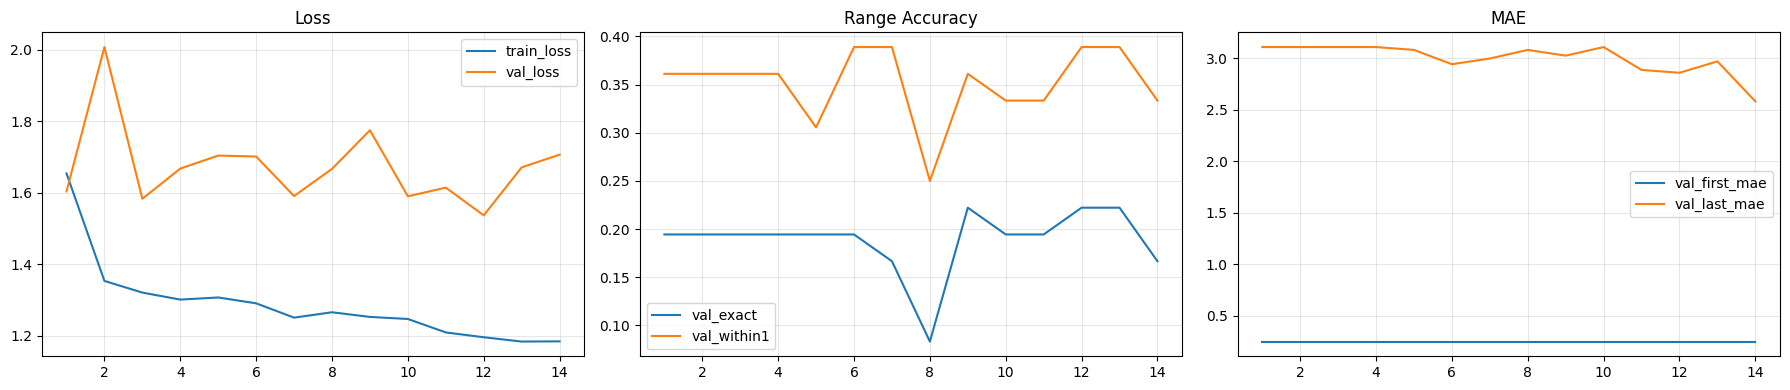

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_range_exact_acc'], label='val_exact')
axes[1].plot(history_df['epoch'], history_df['val_range_within1_acc'], label='val_within1')
axes[1].set_title('Range Accuracy')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_first_mae'], label='val_first_mae')
axes[2].plot(history_df['epoch'], history_df['val_last_mae'], label='val_last_mae')
axes[2].set_title('MAE')
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Inferencia multiclase y clipping por rango visible

En esta seccion comparamos tres escenarios sobre el conjunto de test:

1. `raw`: prediccion multiclase original
2. `oracle_clip`: clipping con rango visible real, para estimar un techo teorico
3. `pred_clip`: clipping con rango visible predicho por el estimador

In [11]:
multiclass_model = UNetEnhanced(in_channels=3, out_channels=num_classes, base=48, dropout=0.10).to(DEVICE)
multiclass_model.load_state_dict(torch.load(MULTICLASS_MODEL_PATH, map_location=DEVICE))
multiclass_model.eval()

test_range_lookup = test_pred_df.set_index('unique_sample_id').to_dict(orient='index')
test_gt_lookup = test_df.set_index('unique_sample_id')[['first_visible_idx', 'last_visible_idx']].to_dict(orient='index')


def prepare_multiclass_sample(row: pd.Series) -> dict:
    image_raw = read_gray(row['radiograph_path_abs'])
    target_raw = build_multiclass_mask(row['multiclass_mask_path_abs'], size=None)
    bbox = (int(row['bbox_x0']), int(row['bbox_y0']), int(row['bbox_x1']), int(row['bbox_y1']))
    image_crop = crop_array(image_raw, bbox)
    target_crop = crop_array(target_raw, bbox)
    image_crop = resize_image(image_crop, IMG_SIZE_MULTICLASS).astype(np.float32) / 255.0
    image_crop = normalize_image(image_crop)
    target_crop = resize_mask(target_crop, IMG_SIZE_MULTICLASS).astype(np.int64)
    coord_channels = build_coordinate_channels(IMG_SIZE_MULTICLASS[0], IMG_SIZE_MULTICLASS[1])
    image_channels = np.concatenate([np.expand_dims(image_crop, axis=0), coord_channels], axis=0)
    return {
        'image_channels': image_channels,
        'target_mask': target_crop,
        'image_gray': image_crop,
    }


def clip_mask_to_range(mask_2d: np.ndarray, first_idx: int, last_idx: int) -> np.ndarray:
    first_idx = int(first_idx)
    last_idx = int(max(last_idx, first_idx))
    allowed_labels = canonical_labels[first_idx:last_idx + 1]
    allowed_ids = {label_to_class_id[label] for label in allowed_labels}
    out = np.zeros_like(mask_2d, dtype=np.int64)
    for class_id in allowed_ids:
        out[mask_2d == class_id] = class_id
    return out


raw_pred_lookup = {}
oracle_clip_lookup = {}
pred_clip_lookup = {}
target_lookup = {}
image_lookup = {}

for _, row in test_df.iterrows():
    prepared = prepare_multiclass_sample(row)
    image_tensor = torch.tensor(prepared['image_channels'][None, ...], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = multiclass_model(image_tensor)
        raw_pred = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.int64)

    sample_id = row['unique_sample_id']
    gt_first = int(test_gt_lookup[sample_id]['first_visible_idx'])
    gt_last = int(test_gt_lookup[sample_id]['last_visible_idx'])
    pred_first = int(test_range_lookup[sample_id]['first_pred_idx'])
    pred_last = int(test_range_lookup[sample_id]['last_pred_idx'])

    raw_pred_lookup[sample_id] = raw_pred
    oracle_clip_lookup[sample_id] = clip_mask_to_range(raw_pred, gt_first, gt_last)
    pred_clip_lookup[sample_id] = clip_mask_to_range(raw_pred, pred_first, pred_last)
    target_lookup[sample_id] = prepared['target_mask']
    image_lookup[sample_id] = prepared['image_gray']

print('Predicciones multiclase evaluadas:', len(raw_pred_lookup))

Predicciones multiclase evaluadas: 45


## 11. Metricas de segmentacion antes y despues del clipping

Aqui respondemos la pregunta central del notebook:

`El rango visible predicho ayuda a reducir sobreprediccion sin destruir la mascara util?`

In [12]:
def metrics_from_prediction_lookup(pred_lookup: dict[str, np.ndarray], target_lookup_in: dict[str, np.ndarray]) -> tuple[pd.DataFrame, pd.DataFrame]:
    intersection = np.zeros(num_classes, dtype=np.float64)
    pred_area = np.zeros(num_classes, dtype=np.float64)
    target_area = np.zeros(num_classes, dtype=np.float64)
    total_valid_correct = 0.0
    total_valid_pixels = 0.0

    for sample_id, pred_mask in pred_lookup.items():
        target_mask = target_lookup_in[sample_id]
        valid = target_mask != IGNORE_INDEX
        total_valid_correct += float((pred_mask[valid] == target_mask[valid]).sum())
        total_valid_pixels += float(valid.sum())
        for class_id in range(num_classes):
            pred_class = pred_mask[valid] == class_id
            target_class = target_mask[valid] == class_id
            intersection[class_id] += np.logical_and(pred_class, target_class).sum()
            pred_area[class_id] += pred_class.sum()
            target_area[class_id] += target_class.sum()

    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
    per_class_df = pd.DataFrame({
        'class_id': np.arange(num_classes),
        'class_name': class_names,
        'pred_pixels': pred_area,
        'target_pixels': target_area,
        'dice': dice,
        'iou': iou,
    })
    per_class_df['region'] = per_class_df['class_name'].map(
        lambda x: 'background' if x == 'background' else ('thoracic' if x.startswith('T') else 'lumbar')
    )
    fg_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
    summary_df = pd.DataFrame([
        {'metric': 'pixel_accuracy', 'value': float((total_valid_correct + 1e-6) / (total_valid_pixels + 1e-6))},
        {'metric': 'macro_dice_fg', 'value': float(fg_df['dice'].mean())},
        {'metric': 'macro_iou_fg', 'value': float(fg_df['iou'].mean())},
        {'metric': 'macro_dice_thoracic', 'value': float(fg_df.loc[fg_df['region'] == 'thoracic', 'dice'].mean())},
        {'metric': 'macro_dice_lumbar', 'value': float(fg_df.loc[fg_df['region'] == 'lumbar', 'dice'].mean())},
    ])
    return summary_df, per_class_df


raw_summary_df, raw_per_class_df = metrics_from_prediction_lookup(raw_pred_lookup, target_lookup)
oracle_summary_df, oracle_per_class_df = metrics_from_prediction_lookup(oracle_clip_lookup, target_lookup)
pred_summary_df, pred_per_class_df = metrics_from_prediction_lookup(pred_clip_lookup, target_lookup)

summary_compare_df = (
    raw_summary_df.rename(columns={'value': 'raw'})
    .merge(oracle_summary_df.rename(columns={'value': 'oracle_clip'}), on='metric')
    .merge(pred_summary_df.rename(columns={'value': 'pred_clip'}), on='metric')
)
summary_compare_df['delta_pred_vs_raw'] = summary_compare_df['pred_clip'] - summary_compare_df['raw']
summary_compare_df['delta_oracle_vs_raw'] = summary_compare_df['oracle_clip'] - summary_compare_df['raw']

display(summary_compare_df)

,metric,raw,oracle_clip,pred_clip,delta_pred_vs_raw,delta_oracle_vs_raw
0,pixel_accuracy,0.813465,0.825100,0.813465,0.0,0.011635
1,macro_dice_fg,0.320511,0.353439,0.320511,0.0,0.032928
2,macro_iou_fg,0.198804,0.225849,0.198804,0.0,0.027044
3,macro_dice_thoracic,0.292598,0.298922,0.292598,0.0,0.006324
4,macro_dice_lumbar,0.387503,0.484280,0.387503,0.0,0.096777


## 12. Analisis por muestra: extra labels y missing labels

Esta comparacion permite ver si el clipping por rango visible realmente reduce
sobreprediccion, y cuanto cuesta en vertebras faltantes.

In [13]:
def present_labels_from_mask(mask_2d: np.ndarray) -> list[str]:
    ids = sorted([int(x) for x in np.unique(mask_2d) if int(x) > 0])
    return [class_names[i] for i in ids]


per_sample_rows = []
for _, row in test_df.iterrows():
    sample_id = row['unique_sample_id']
    target_mask = target_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    pred_mask = pred_clip_lookup[sample_id]

    gt_labels = present_labels_from_mask(np.where(target_mask == IGNORE_INDEX, 0, target_mask))
    raw_labels = present_labels_from_mask(raw_mask)
    oracle_labels = present_labels_from_mask(oracle_mask)
    pred_labels = present_labels_from_mask(pred_mask)

    per_sample_rows.append({
        'unique_sample_id': sample_id,
        'split': row['split'],
        'image': row['image'],
        'gt_first_label': canonical_labels[int(row['first_visible_idx'])],
        'gt_last_label': canonical_labels[int(row['last_visible_idx'])],
        'pred_first_label': test_range_lookup[sample_id]['first_pred_label'],
        'pred_last_label': test_range_lookup[sample_id]['last_pred_label'],
        'gt_labels': ', '.join(gt_labels),
        'raw_labels': ', '.join(raw_labels),
        'oracle_labels': ', '.join(oracle_labels),
        'pred_clip_labels': ', '.join(pred_labels),
        'raw_extra_count': len(set(raw_labels) - set(gt_labels)),
        'oracle_extra_count': len(set(oracle_labels) - set(gt_labels)),
        'pred_extra_count': len(set(pred_labels) - set(gt_labels)),
        'raw_missing_count': len(set(gt_labels) - set(raw_labels)),
        'oracle_missing_count': len(set(gt_labels) - set(oracle_labels)),
        'pred_missing_count': len(set(gt_labels) - set(pred_labels)),
    })

per_sample_compare_df = pd.DataFrame(per_sample_rows)
per_sample_compare_df['pred_extra_reduction_vs_raw'] = per_sample_compare_df['raw_extra_count'] - per_sample_compare_df['pred_extra_count']
per_sample_compare_df['pred_missing_change_vs_raw'] = per_sample_compare_df['pred_missing_count'] - per_sample_compare_df['raw_missing_count']

presence_summary_df = pd.DataFrame([
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_oracle_extra_count', 'value': float(per_sample_compare_df['oracle_extra_count'].mean())},
    {'metric': 'mean_pred_extra_count', 'value': float(per_sample_compare_df['pred_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_oracle_missing_count', 'value': float(per_sample_compare_df['oracle_missing_count'].mean())},
    {'metric': 'mean_pred_missing_count', 'value': float(per_sample_compare_df['pred_missing_count'].mean())},
    {'metric': 'samples_with_pred_extra_reduction', 'value': int((per_sample_compare_df['pred_extra_reduction_vs_raw'] > 0).sum())},
    {'metric': 'samples_with_pred_missing_increase', 'value': int((per_sample_compare_df['pred_missing_change_vs_raw'] > 0).sum())},
])

display(presence_summary_df)
display(per_sample_compare_df.sort_values(['pred_extra_reduction_vs_raw', 'pred_missing_change_vs_raw'], ascending=[False, True]).head(20))

,metric,value
0,mean_raw_extra_count,3.022222
1,mean_oracle_extra_count,0.000000
2,mean_pred_extra_count,3.022222
3,mean_raw_missing_count,0.022222
4,mean_oracle_missing_count,0.022222
5,mean_pred_missing_count,0.022222
6,samples_with_pred_extra_reduction,0.000000
7,samples_with_pred_missing_increase,0.000000


,unique_sample_id,split,image,gt_first_label,gt_last_label,pred_first_label,pred_last_label,gt_labels,raw_labels,oracle_labels,pred_clip_labels,raw_extra_count,oracle_extra_count,pred_extra_count,raw_missing_count,oracle_missing_count,pred_missing_count,pred_extra_reduction_vs_raw,pred_missing_change_vs_raw
0,Normal__N_4.jpg,Normal,N_4.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
1,Normal__N_6.jpg,Normal,N_6.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
2,Normal__N_8.jpg,Normal,N_8.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
3,Normal__N_15.jpg,Normal,N_15.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
4,Normal__N_18.jpg,Normal,N_18.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
5,Normal__N_19.jpg,Normal,N_19.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
6,Normal__N_23.jpg,Normal,N_23.jpg,T1,L4,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",1,0,1,0,0,0,0,0
7,Normal__N_24.jpg,Normal,N_24.jpg,T1,L5,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,0,0,0,0
8,Normal__N_26.jpg,Normal,N_26.jpg,T1,L3,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",2,0,2,0,0,0,0,0
9,Normal__N_27.jpg,Normal,N_27.jpg,T1,L2,T1,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",3,0,3,0,0,0,0,0


## 13. Visualizacion cualitativa

Revisamos ejemplos donde el clipping por rango visible parece ayudar mas, para
validar si la mejora es anatomica y no solo numerica.

Muestras seleccionadas: ['Scoliosis__S_70.jpg', 'Scoliosis__S_72.jpg', 'Scoliosis__S_84.jpg', 'Scoliosis__S_28.jpg', 'Scoliosis__S_24.jpg', 'Scoliosis__S_48.jpg', 'Scoliosis__S_64.jpg', 'Scoliosis__S_180.jpg']


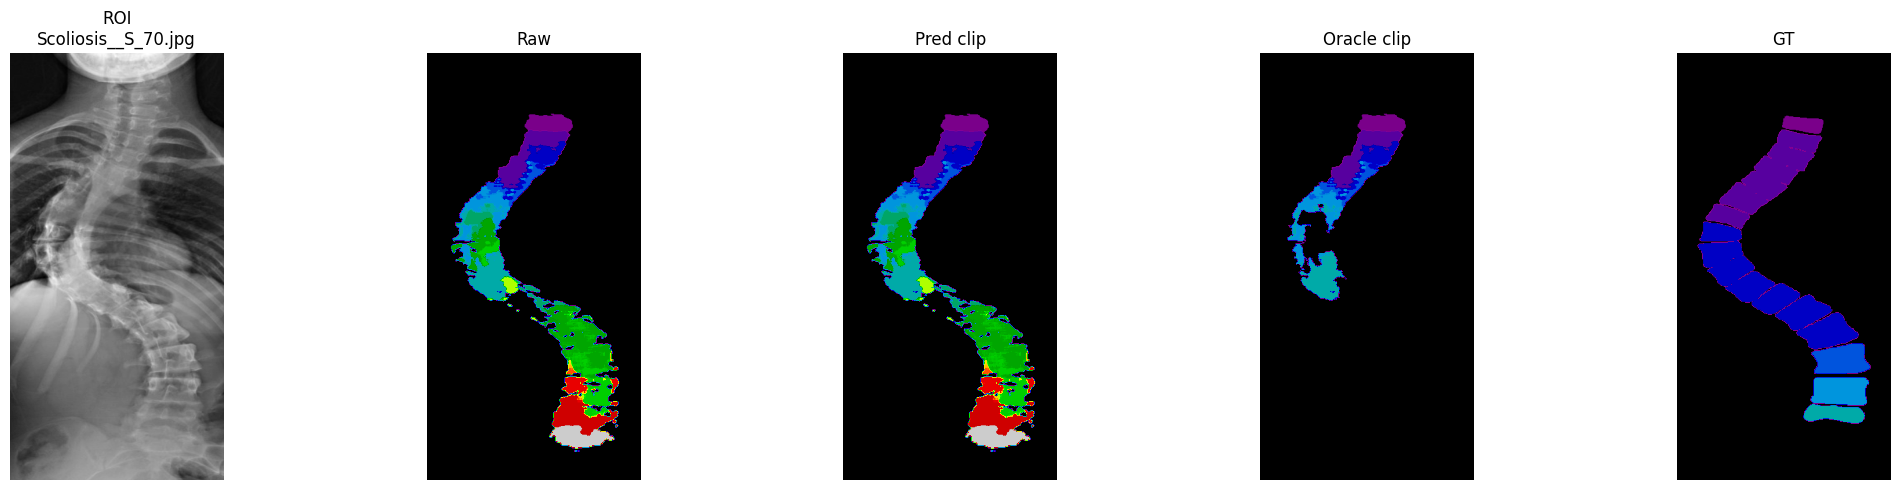

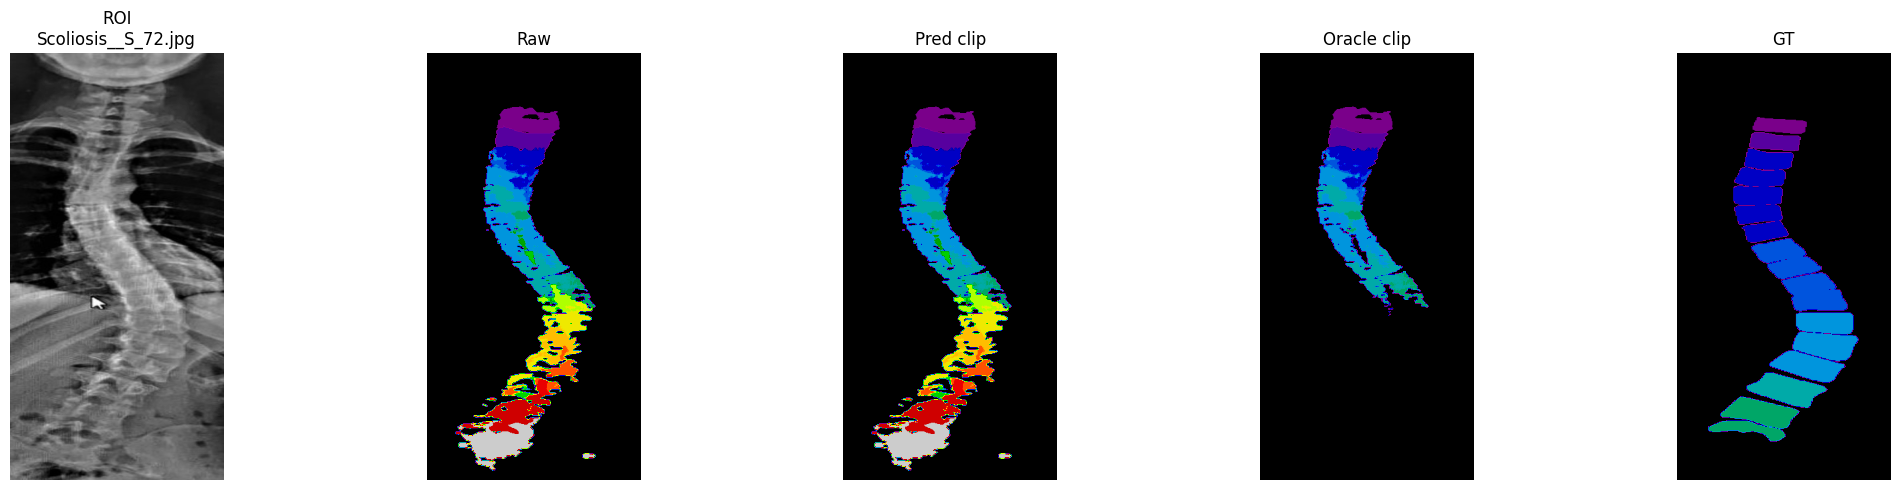

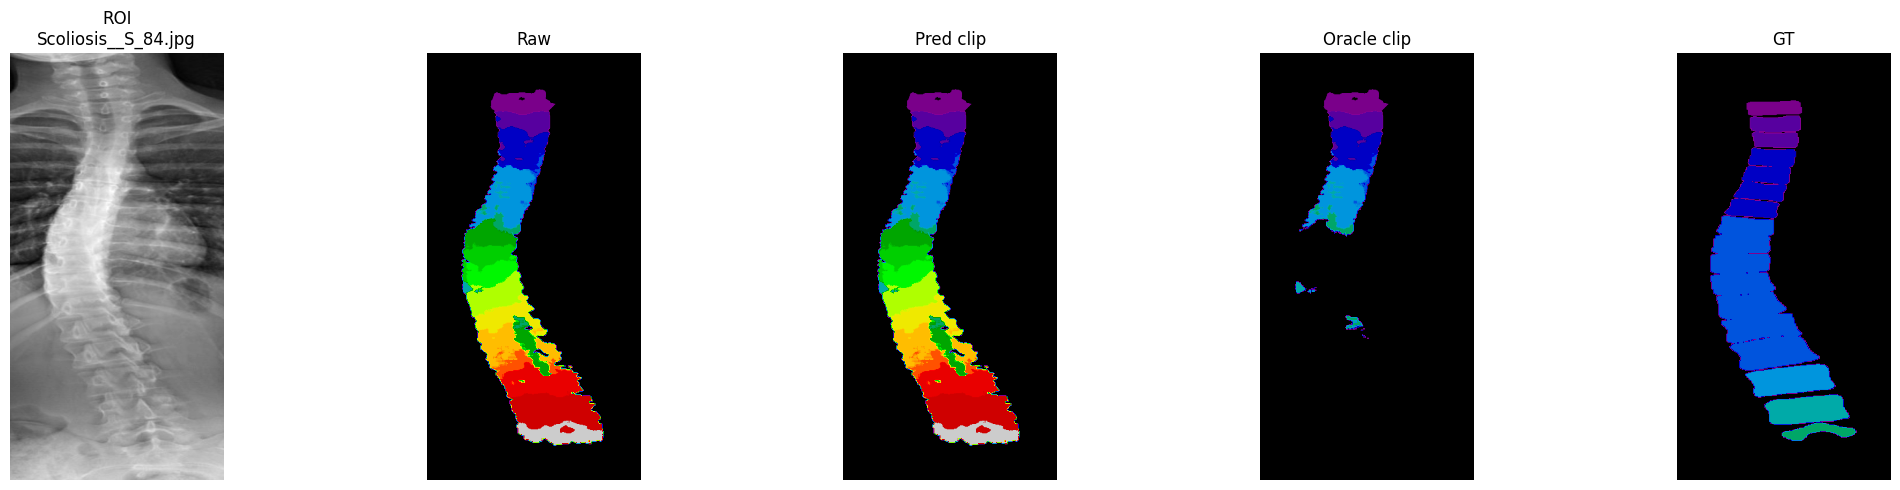

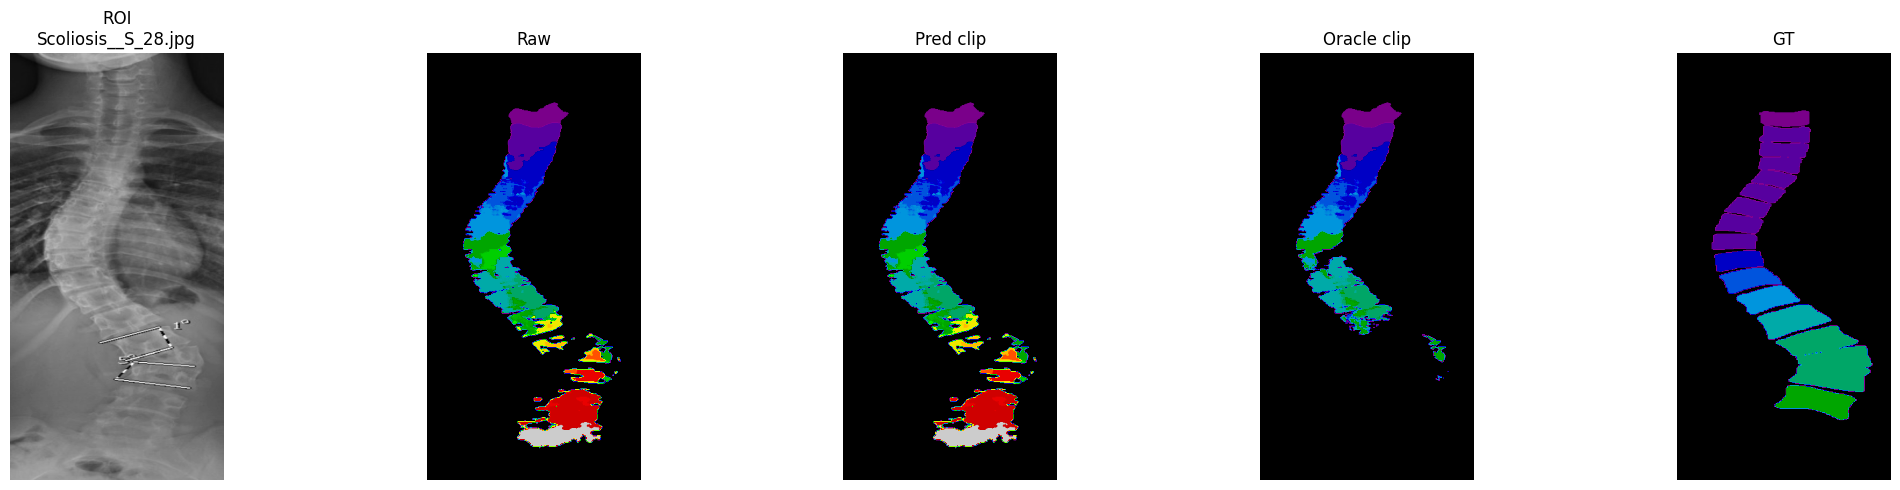

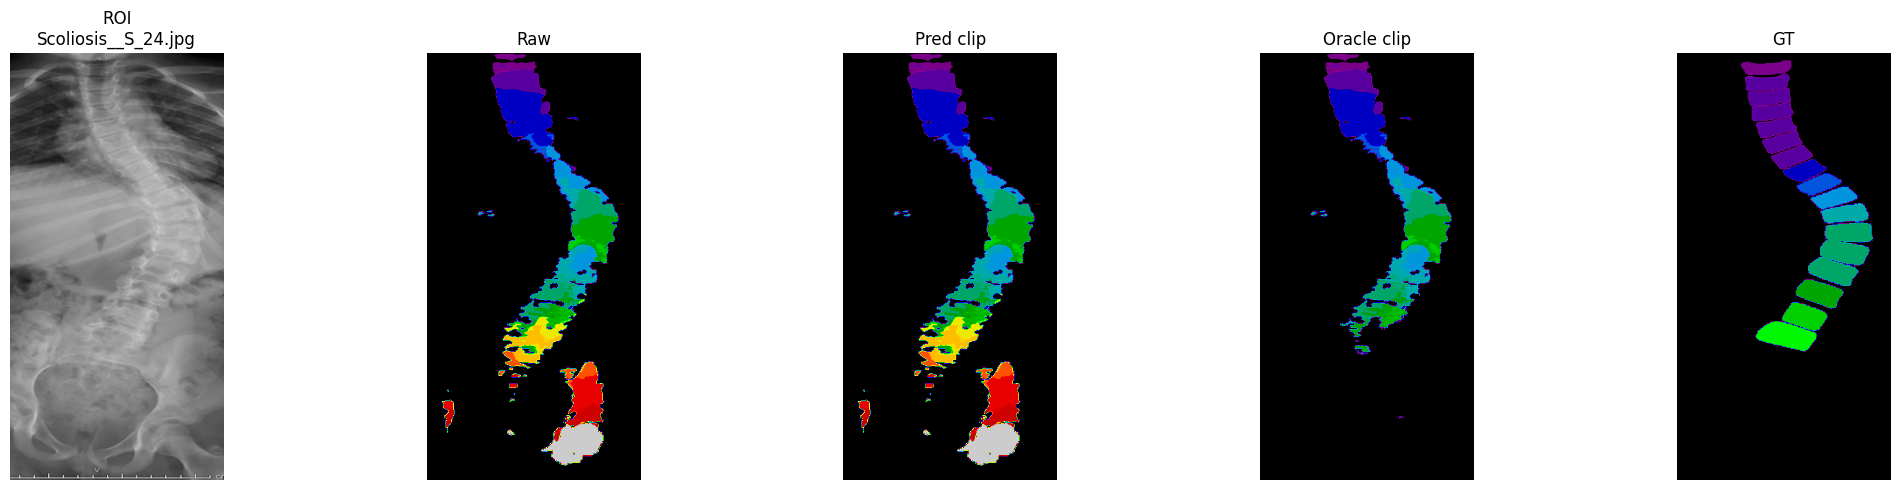

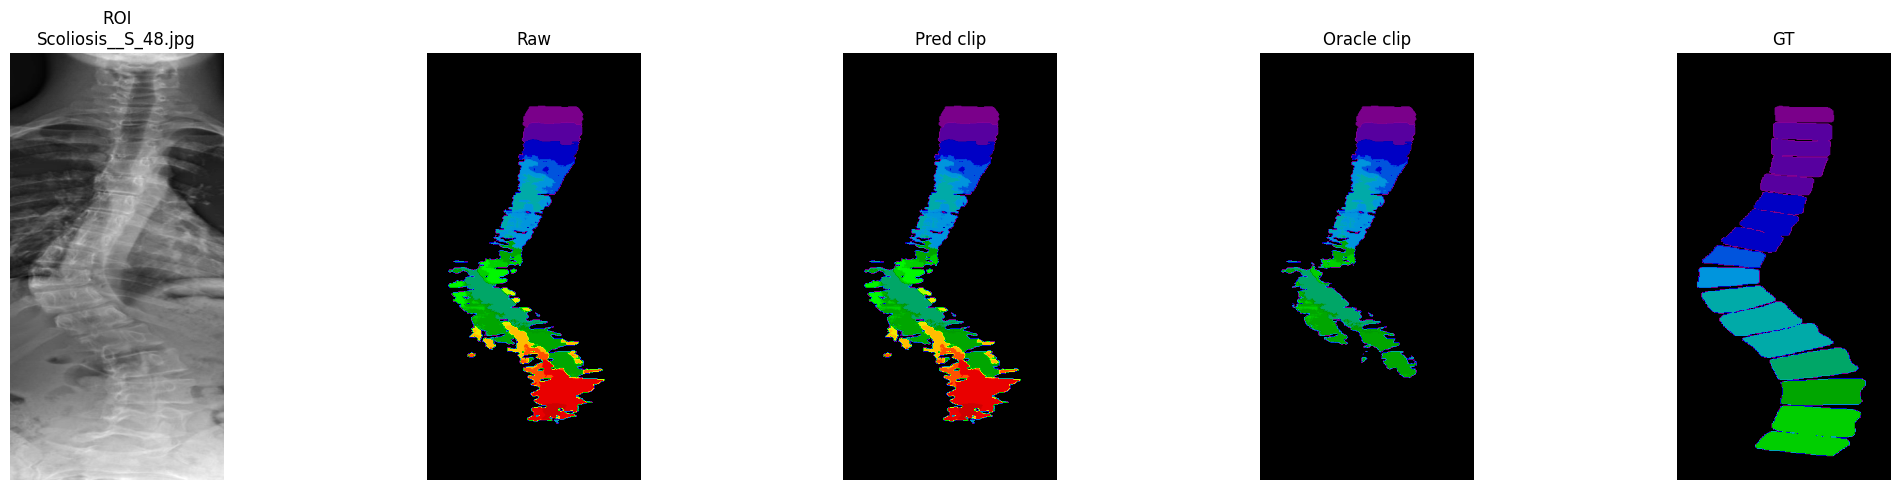

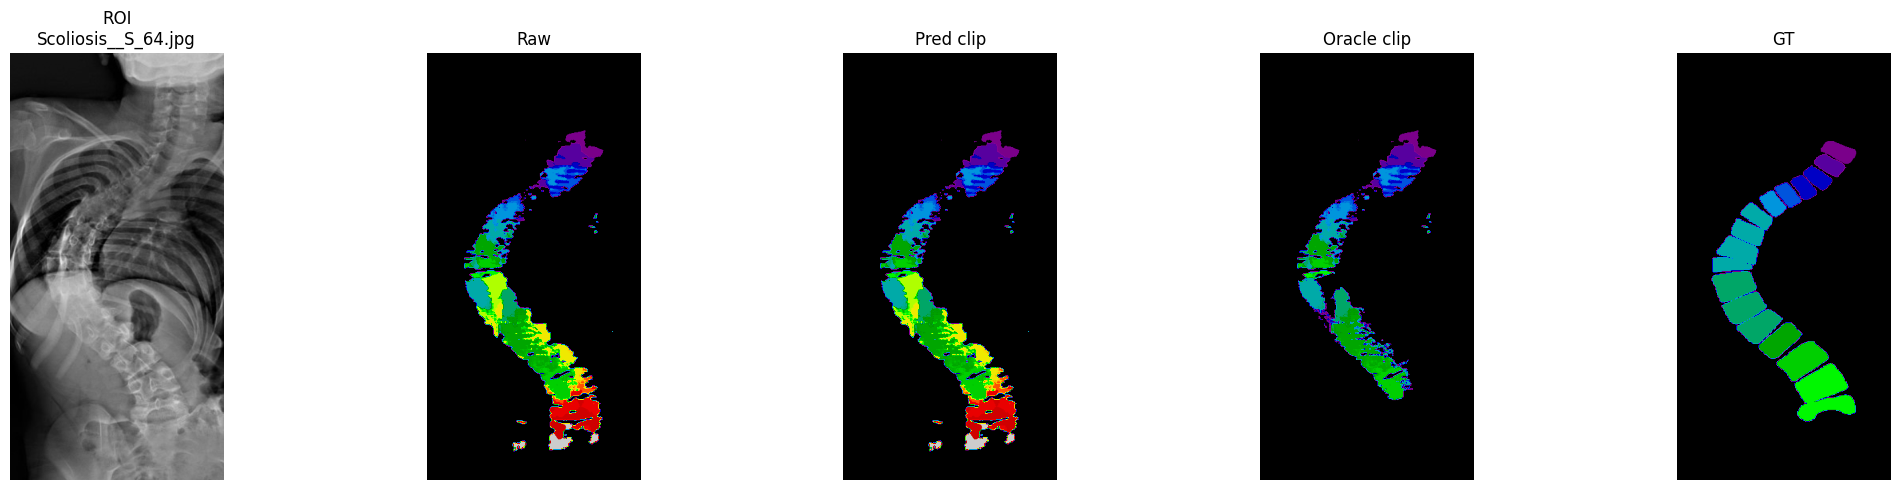

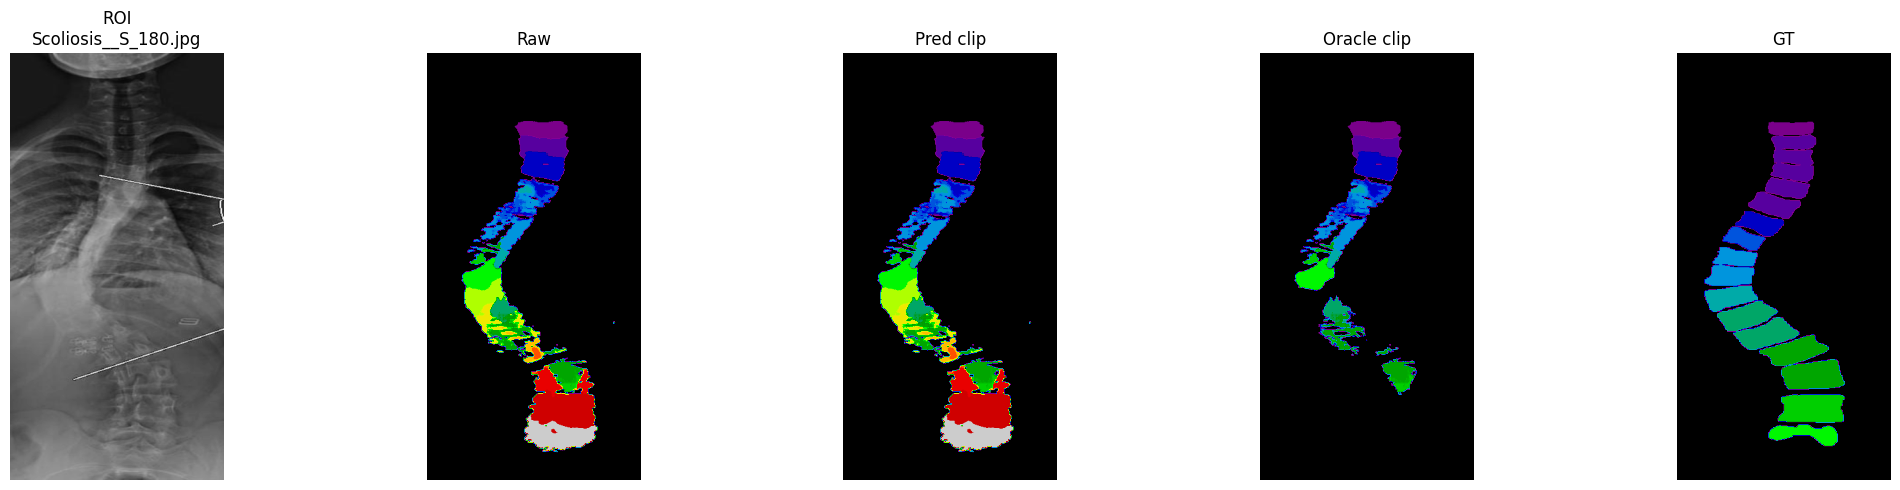

In [14]:
def show_sample(sample_id: str) -> None:
    image_gray = image_lookup[sample_id]
    raw_mask = raw_pred_lookup[sample_id]
    oracle_mask = oracle_clip_lookup[sample_id]
    pred_mask = pred_clip_lookup[sample_id]
    target_mask = target_lookup[sample_id].copy()
    target_mask[target_mask == IGNORE_INDEX] = 0

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    axes[0].imshow(image_gray, cmap='gray')
    axes[0].set_title(f'ROI\n{sample_id}')
    axes[1].imshow(raw_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[1].set_title('Raw')
    axes[2].imshow(pred_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[2].set_title('Pred clip')
    axes[3].imshow(oracle_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[3].set_title('Oracle clip')
    axes[4].imshow(target_mask, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
    axes[4].set_title('GT')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


sample_ids_to_show = per_sample_compare_df.sort_values(
    ['pred_extra_reduction_vs_raw', 'pred_missing_change_vs_raw', 'raw_extra_count'],
    ascending=[False, True, False],
)['unique_sample_id'].head(N_VIS_SAMPLES).tolist()

print('Muestras seleccionadas:', sample_ids_to_show)
for sample_id in sample_ids_to_show:
    show_sample(sample_id)

## 14. Exportacion de resultados

Guardamos:

- historia de entrenamiento
- predicciones del estimador de rango
- metricas de segmentacion raw/oracle/pred_clip
- comparacion por muestra

In [15]:
history_path = OUTPUT_DIR / 'visible_range_history.csv'
range_summary_path = OUTPUT_DIR / 'visible_range_summary.csv'
train_pred_path = OUTPUT_DIR / 'visible_range_train_predictions.csv'
val_pred_path = OUTPUT_DIR / 'visible_range_val_predictions.csv'
test_pred_path = OUTPUT_DIR / 'visible_range_test_predictions.csv'
summary_compare_path = OUTPUT_DIR / 'clipping_metric_comparison.csv'
raw_per_class_path = OUTPUT_DIR / 'clipping_raw_per_class.csv'
oracle_per_class_path = OUTPUT_DIR / 'clipping_oracle_per_class.csv'
pred_per_class_path = OUTPUT_DIR / 'clipping_pred_per_class.csv'
presence_summary_path = OUTPUT_DIR / 'clipping_presence_summary.csv'
per_sample_path = OUTPUT_DIR / 'clipping_per_sample_compare.csv'

history_df.to_csv(history_path, index=False)
range_summary_df.to_csv(range_summary_path, index=False)
train_pred_df.to_csv(train_pred_path, index=False)
val_pred_df.to_csv(val_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)
summary_compare_df.to_csv(summary_compare_path, index=False)
raw_per_class_df.to_csv(raw_per_class_path, index=False)
oracle_per_class_df.to_csv(oracle_per_class_path, index=False)
pred_per_class_df.to_csv(pred_per_class_path, index=False)
presence_summary_df.to_csv(presence_summary_path, index=False)
per_sample_compare_df.to_csv(per_sample_path, index=False)

experiment_summary_df = pd.DataFrame([
    {'metric': 'target_subset', 'value': TARGET_SUBSET},
    {'metric': 'test_samples', 'value': int(len(test_df))},
    {'metric': 'range_test_exact_acc', 'value': float(test_metrics['range_exact_acc'])},
    {'metric': 'range_test_within1_acc', 'value': float(test_metrics['range_within1_acc'])},
    {'metric': 'raw_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'raw'].iloc[0])},
    {'metric': 'oracle_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'oracle_clip'].iloc[0])},
    {'metric': 'pred_clip_macro_dice_fg', 'value': float(summary_compare_df.loc[summary_compare_df['metric'] == 'macro_dice_fg', 'pred_clip'].iloc[0])},
    {'metric': 'mean_raw_extra_count', 'value': float(per_sample_compare_df['raw_extra_count'].mean())},
    {'metric': 'mean_oracle_extra_count', 'value': float(per_sample_compare_df['oracle_extra_count'].mean())},
    {'metric': 'mean_pred_extra_count', 'value': float(per_sample_compare_df['pred_extra_count'].mean())},
    {'metric': 'mean_raw_missing_count', 'value': float(per_sample_compare_df['raw_missing_count'].mean())},
    {'metric': 'mean_pred_missing_count', 'value': float(per_sample_compare_df['pred_missing_count'].mean())},
])
experiment_summary_path = OUTPUT_DIR / 'visible_range_experiment_summary.csv'
experiment_summary_df.to_csv(experiment_summary_path, index=False)

display(experiment_summary_df)
print('Guardado:', history_path)
print('Guardado:', range_summary_path)
print('Guardado:', train_pred_path)
print('Guardado:', val_pred_path)
print('Guardado:', test_pred_path)
print('Guardado:', summary_compare_path)
print('Guardado:', raw_per_class_path)
print('Guardado:', oracle_per_class_path)
print('Guardado:', pred_per_class_path)
print('Guardado:', presence_summary_path)
print('Guardado:', per_sample_path)
print('Guardado:', experiment_summary_path)

,metric,value
0,target_subset,partial
1,test_samples,45
2,range_test_exact_acc,0.288889
3,range_test_within1_acc,0.466667
4,raw_macro_dice_fg,0.320511
5,oracle_macro_dice_fg,0.353439
6,pred_clip_macro_dice_fg,0.320511
7,mean_raw_extra_count,3.022222
8,mean_oracle_extra_count,0.0
9,mean_pred_extra_count,3.022222


Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_history.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_summary.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_train_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_val_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Dataset/analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_test_predictions.csv
Guardado: /Users/camilo/Documents/WorkSpace/IA-MASTER/ProyectoGrado2/Scoliosis_Data